In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [2]:
# 1. Generate synthetic data with a true non-linear relationship
np.random.seed(42)
X = np.sort(np.random.rand(30, 1) * 6, axis=0)
# True relationship is a sine wave, but we add random noise
y = np.sin(X).ravel() + np.random.normal(0, 0.3, X.shape[0])

In [3]:
# Generate a smooth line for plotting the true function
X_plot = np.linspace(0, 6, 100)[:, np.newaxis]
y_true = np.sin(X_plot).ravel()

In [4]:
# 2. Define our two competing models
# Model A: Degree 1 (Simple Linear Regression) -> High Bias
model_high_bias = LinearRegression()
model_high_bias.fit(X, y)

LinearRegression()

In [5]:
# Model B: Degree 15 (Complex Polynomial) -> High Variance
model_high_variance = make_pipeline(PolynomialFeatures(degree=15), LinearRegression())
model_high_variance.fit(X, y)

Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(degree=15)),
                ('linearregression', LinearRegression())])

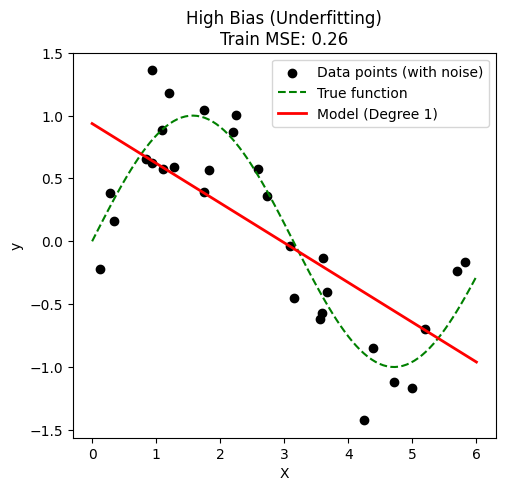

In [6]:
# 3. Plotting the results
plt.figure(figsize=(12, 5))

# Plot High Bias (Underfitting)
plt.subplot(1, 2, 1)
plt.scatter(X, y, color='black', label='Data points (with noise)')
plt.plot(X_plot, y_true, color='green', linestyle='--', label='True function')
plt.plot(X_plot, model_high_bias.predict(X_plot), color='red', linewidth=2, label='Model (Degree 1)')
plt.title(f"High Bias (Underfitting)\nTrain MSE: {mean_squared_error(y, model_high_bias.predict(X)):.2f}")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()

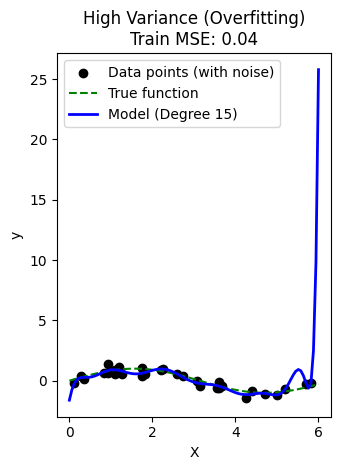

In [7]:
# Plot High Variance (Overfitting)
plt.subplot(1, 2, 2)
plt.scatter(X, y, color='black', label='Data points (with noise)')
plt.plot(X_plot, y_true, color='green', linestyle='--', label='True function')
plt.plot(X_plot, model_high_variance.predict(X_plot), color='blue', linewidth=2, label='Model (Degree 15)')
plt.title(f"High Variance (Overfitting)\nTrain MSE: {mean_squared_error(y, model_high_variance.predict(X)):.2f}")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()

plt.tight_layout()
plt.show()